# Gopay Google App Review Scraping

**Author:** Muhammad Razan Parisya Putra  
**Notebook:** `1 - Gopay Review Scrapping`

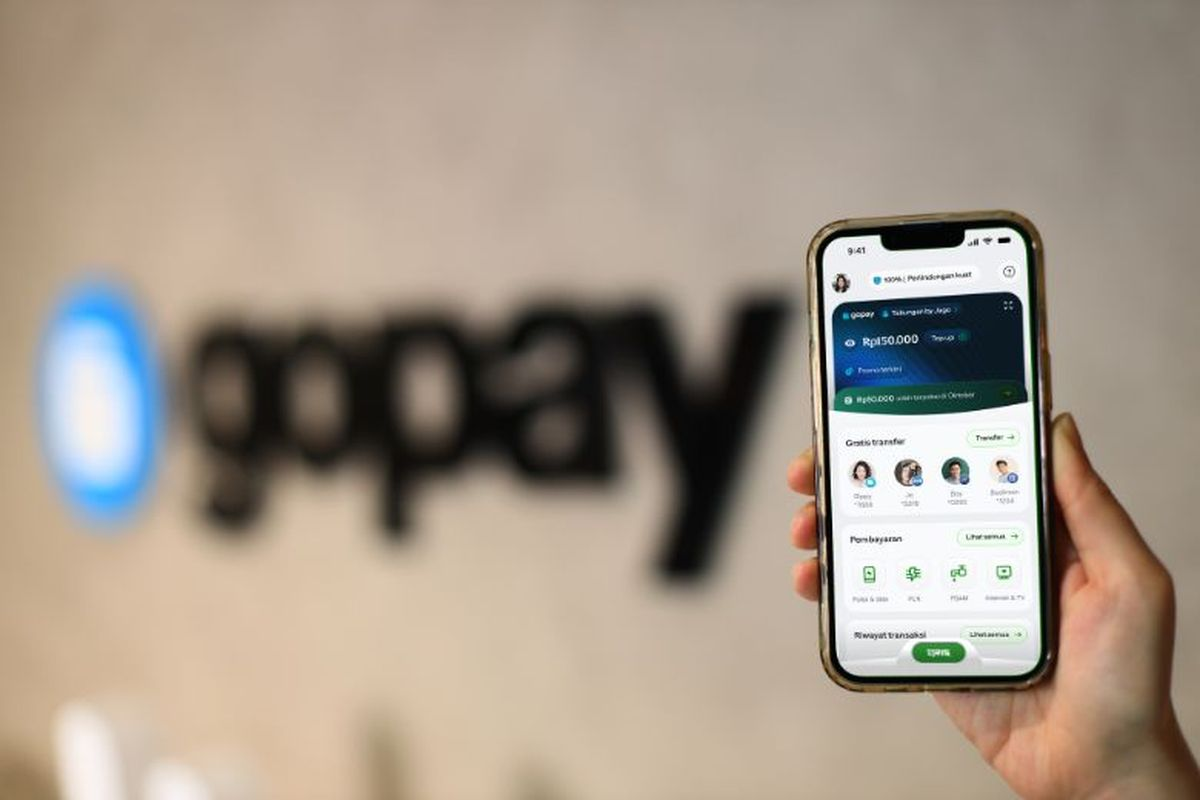

## Instalation & Prerequisites

In [ ]:
!pip install google_play_scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.4 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import app
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns

## Data Scrapping

In [ ]:
from google_play_scraper import app, Sort, reviews_all

gopay_reviews = reviews_all(
    'com.gojek.gopay', # Google Play id for gopay
    sleep_milliseconds=0,
    lang='id', # review language
    sort=Sort.NEWEST,
)

In [ ]:
df_result = pd.DataFrame(np.array(gopay_reviews),columns=['content'])
df_result = df_result.join(pd.DataFrame(df_result.pop('content').tolist()))
df_result.to_csv(r'df_review_gopay.csv', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df_result

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,888c9e2d-b048-4ff5-9dc2-19582ad89693,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,0,2.3.0,2026-02-28 15:16:28,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",2026-02-28 15:04:54,2.3.0
1,b3a1f5ab-6c0f-489a-9539-79ab670053a8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,busuk,1,0,2.3.0,2026-02-28 15:14:08,None,NaT,2.3.0
2,e5045dd9-d082-4158-be52-6d455729cd53,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,selalu dapat bonus,5,0,2.3.0,2026-02-28 15:12:17,None,NaT,2.3.0
3,5fa3f408-c649-4c02-b7fc-f644fbb0ec57,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"good, kasih donk promonya",5,0,2.3.0,2026-02-28 15:10:00,None,NaT,2.3.0
4,13dafdbe-e031-4a44-ae1f-630fb257a6ec,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,terbaik mendukung bwnget,5,0,2.0.3,2026-02-28 15:08:01,None,NaT,2.0.3
...,...,...,...,...,...,...,...,...,...,...,...
367190,5c496d7c-b569-4189-848d-cb7ba43ee5be,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ribet asw mau buka akun aja susah baru kli ini...,1,3,None,2023-04-08 13:27:16,"Hai Irfa, saat ini aplikasi GoPay masih berada...",2023-04-10 04:40:43,None
367191,ff92fd6c-c714-44c6-a740-164111046cf5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kok gk ada ulasan lain?,5,1,None,2023-04-08 09:37:00,None,NaT,None
367192,6d7088a1-feff-4a2f-8b8b-c9e0a6ffe1ff,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Susah masuknya malah anti trus,1,11,1.0.0,2023-04-08 08:41:47,"Hai Erwin, saat ini aplikasi GoPay masih berad...",2023-04-10 04:43:43,1.0.0
367193,82870e75-2a01-4968-a6d7-8ccea03e43d9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Terima kasih,2,4,None,2023-04-08 06:23:30,None,NaT,None


In [ ]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367195 entries, 0 to 367194
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              367195 non-null  object        
 1   userName              367195 non-null  object        
 2   userImage             367195 non-null  object        
 3   content               367195 non-null  object        
 4   score                 367195 non-null  int64         
 5   thumbsUpCount         367195 non-null  int64         
 6   reviewCreatedVersion  306103 non-null  object        
 7   at                    367195 non-null  datetime64[ns]
 8   replyContent          61660 non-null   object        
 9   repliedAt             61660 non-null   datetime64[ns]
 10  appVersion            306103 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 30.8+ MB


In [ ]:
# Selected Columns
df_analysis = df_result.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]
df_analysis

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,0,2.3.0,2026-02-28 15:16:28,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",2026-02-28 15:04:54
1,busuk,1,0,2.3.0,2026-02-28 15:14:08,None,NaT
2,selalu dapat bonus,5,0,2.3.0,2026-02-28 15:12:17,None,NaT
3,"good, kasih donk promonya",5,0,2.3.0,2026-02-28 15:10:00,None,NaT
4,terbaik mendukung bwnget,5,0,2.0.3,2026-02-28 15:08:01,None,NaT
...,...,...,...,...,...,...,...
367190,Ribet asw mau buka akun aja susah baru kli ini...,1,3,None,2023-04-08 13:27:16,"Hai Irfa, saat ini aplikasi GoPay masih berada...",2023-04-10 04:40:43
367191,Kok gk ada ulasan lain?,5,1,None,2023-04-08 09:37:00,None,NaT
367192,Susah masuknya malah anti trus,1,11,1.0.0,2023-04-08 08:41:47,"Hai Erwin, saat ini aplikasi GoPay masih berad...",2023-04-10 04:43:43
367193,Terima kasih,2,4,None,2023-04-08 06:23:30,None,NaT


In [ ]:
# Distribution of reviews score
df_result['score'].value_counts()

,count
score,
5,267428
1,54526
4,23461
3,12619
2,9161


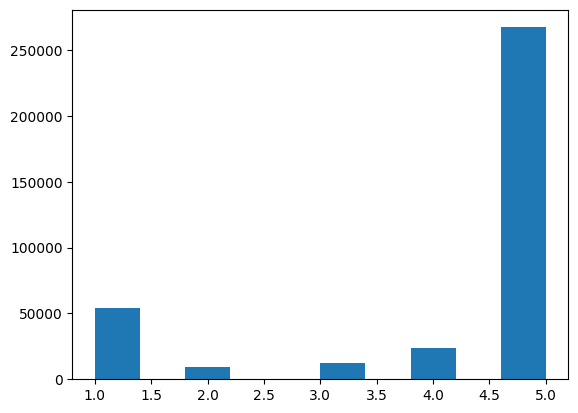

In [ ]:
plt.hist(df_result['score'])
plt.show()